Практика 4.1
Студент Карелин Д.В.
Вариант 6

**Задание 1**

Сравнение ElasticNet

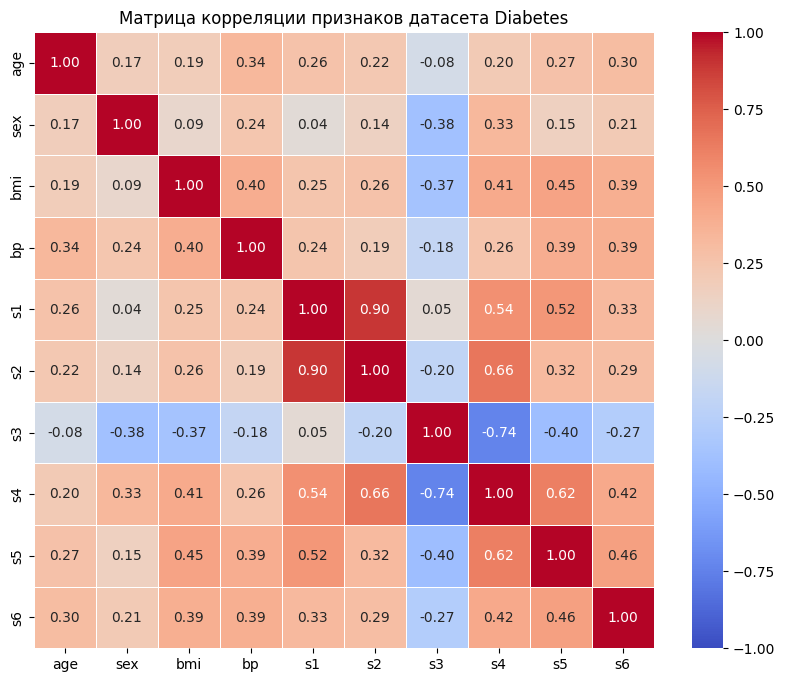

        Model       RMSE  Non-zero coefs
0       Ridge  53.485346              10
1       Lasso  53.496765               9
2  ElasticNet  53.494263               9

ElasticNet best alpha: 0.07880462815669913
ElasticNet best l1_ratio: 1.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge, Lasso, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

data = load_diabetes()
X, y = data.data, data.target

df_features = pd.DataFrame(X, columns=data.feature_names)
corr_matrix = df_features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Матрица корреляции признаков датасета Diabetes")
plt.show()

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1, max_iter=10000))
])

elastic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 1],
        alphas=np.logspace(-4, 2, 30),
        cv=5,
        max_iter=10000
    ))
])

models = {
    "Ridge": ridge,
    "Lasso": lasso,
    "ElasticNet": elastic
}

results = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)

    rmse = np.sqrt(mean_squared_error(y, y_pred))
    coefs = model.named_steps['model'].coef_
    non_zero = np.sum(coefs != 0)

    results.append([name, rmse, non_zero])

df = pd.DataFrame(results, columns=["Model", "RMSE", "Non-zero coefs"])
print(df)

elastic_model = elastic.named_steps['model']
print("\nElasticNet best alpha:", elastic_model.alpha_)
print("ElasticNet best l1_ratio:", elastic_model.l1_ratio_)


На кросс-валидации ElasticNet сам выбрал l1_ratio = 1.0, то есть полностью превратился в Lasso. В датасете Diabetes оказался лишний  признак(шум), но при этом не было мультиколлинеарности. Чистый Lasso идеально подошел, так как он выкинул ненужный признак , сохранив ту же точность предсказания RMSE, что и Ridge, который содержал в себе все 10 признаков.

Задание 2 - Влияние объема данных

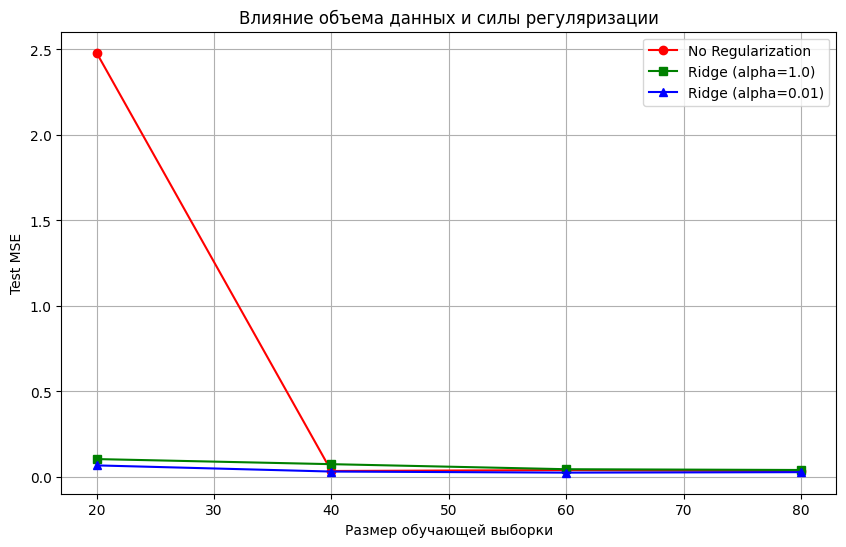

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, 100)

sizes = [20, 40, 60, 80]
linear_errors = []
ridge_strong_errors = []
ridge_weak_errors = []

for size in sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=size, random_state=42)

    # Linear (без регуляризации)
    model_lin = Pipeline([
        ('poly', PolynomialFeatures(degree=10)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=0))
    ])

    # Ridge (сильная регуляризация)
    model_ridge_strong = Pipeline([
        ('poly', PolynomialFeatures(degree=10)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ])

    # Ridge (слабая регуляризация)
    model_ridge_weak = Pipeline([
        ('poly', PolynomialFeatures(degree=10)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=0.01))
    ])

    model_lin.fit(X_train, y_train)
    model_ridge_strong.fit(X_train, y_train)
    model_ridge_weak.fit(X_train, y_train)

    y_pred_lin = model_lin.predict(X_test)
    y_pred_ridge_strong = model_ridge_strong.predict(X_test)
    y_pred_ridge_weak = model_ridge_weak.predict(X_test)

    linear_errors.append(mean_squared_error(y_test, y_pred_lin))
    ridge_strong_errors.append(mean_squared_error(y_test, y_pred_ridge_strong))
    ridge_weak_errors.append(mean_squared_error(y_test, y_pred_ridge_weak))

plt.figure(figsize=(10, 6))
plt.plot(sizes, linear_errors, marker='o', color='red', label='No Regularization')
plt.plot(sizes, ridge_strong_errors, marker='s', color='green', label='Ridge (alpha=1.0)')
plt.plot(sizes, ridge_weak_errors, marker='^', color='blue', label='Ridge (alpha=0.01)')
plt.xlabel("Размер обучающей выборки")
plt.ylabel("Test MSE")
plt.title("Влияние объема данных и силы регуляризации")
plt.legend()
plt.grid()
plt.show()

При малом количестве данных регуляризация существенно улучшает качество модели (снижает ошибку)

При увеличении объема данных разница между моделями уменьшается (мб даже ПРОПАДАЕТ)

Задание 3 - Анализ остатков

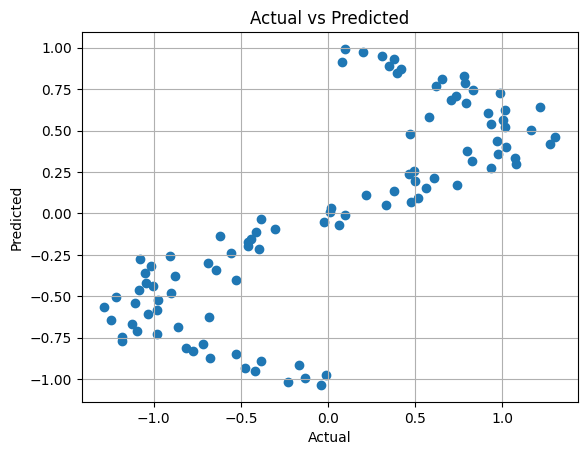

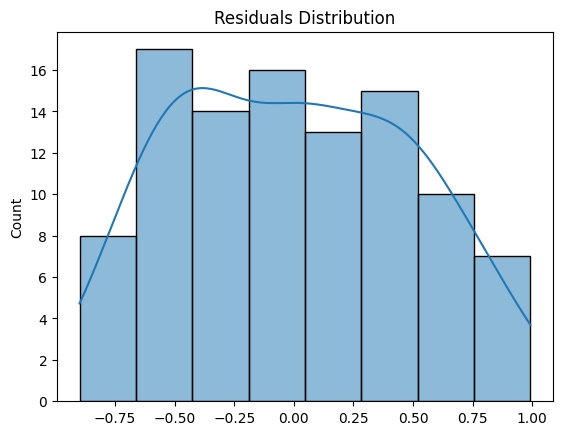

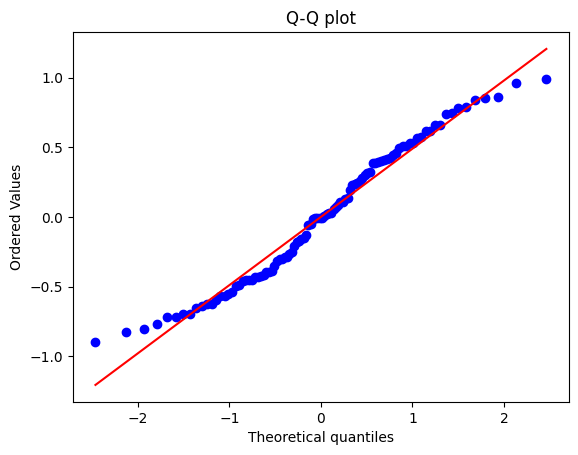

Shapiro p-value: 0.017300311533314704


In [ ]:
import seaborn as sns
from scipy import stats

# берём лучшую модель (например Ridge или ElasticNet)
best_model = ridge
best_model.fit(X, y)

y_pred = best_model.predict(X)
residuals = y - y_pred

# 1. Actual vs Predicted
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid()
plt.show()

# 2. Гистограмма остатков
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot")
plt.show()

# 4. Shapiro test
stat, p = stats.shapiro(residuals)
print("Shapiro p-value:", p)

График Actual vs Predicted показывает выраженную нелинейную структуру данных -  точки образуют петли, а не ровную линию. Линейная модель Ridge не способна описать такую сложную зависимость, из-за чего возникают систематические крупные ошибки предсказания. Именно эта нелинейность взаимосвязей и является причиной того, что остатки модели распределены ненормально.  Гетероскедастичности (разного масштаба ошибок) здесь нет, так как ширина этого облака точек остается примерно одинаковой на всем протяжении диапазона — точки не расходятся веером